In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

### Prepare the data

In [ ]:
data = load_iris() #shift+tab

In [ ]:
df = pd.DataFrame()
df['sepal length'] = data['data'][:,0]
df['sepal width'] = data['data'][:,1]
df['petal length'] = data['data'][:,2]
##df['petal width'] = data['data'][:,3]  ## Ignoring this feature

In [ ]:
display(df)

,sepal length,sepal width,petal length
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4
...,...,...,...
145,6.7,3.0,5.2
146,6.3,2.5,5.0
147,6.5,3.0,5.2
148,6.2,3.4,5.4


In [ ]:
X = df.to_numpy() # These are our features

In [ ]:
df['target'] = data['target']

In [ ]:
named_targets = []

for elm in df['target'].to_list():
    named_targets.append(data.target_names[elm])


In [ ]:
df['species_name'] = named_targets

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_740/3728932651.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.legend(handles, [legend_labels[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels], title='Species', loc='upper left')


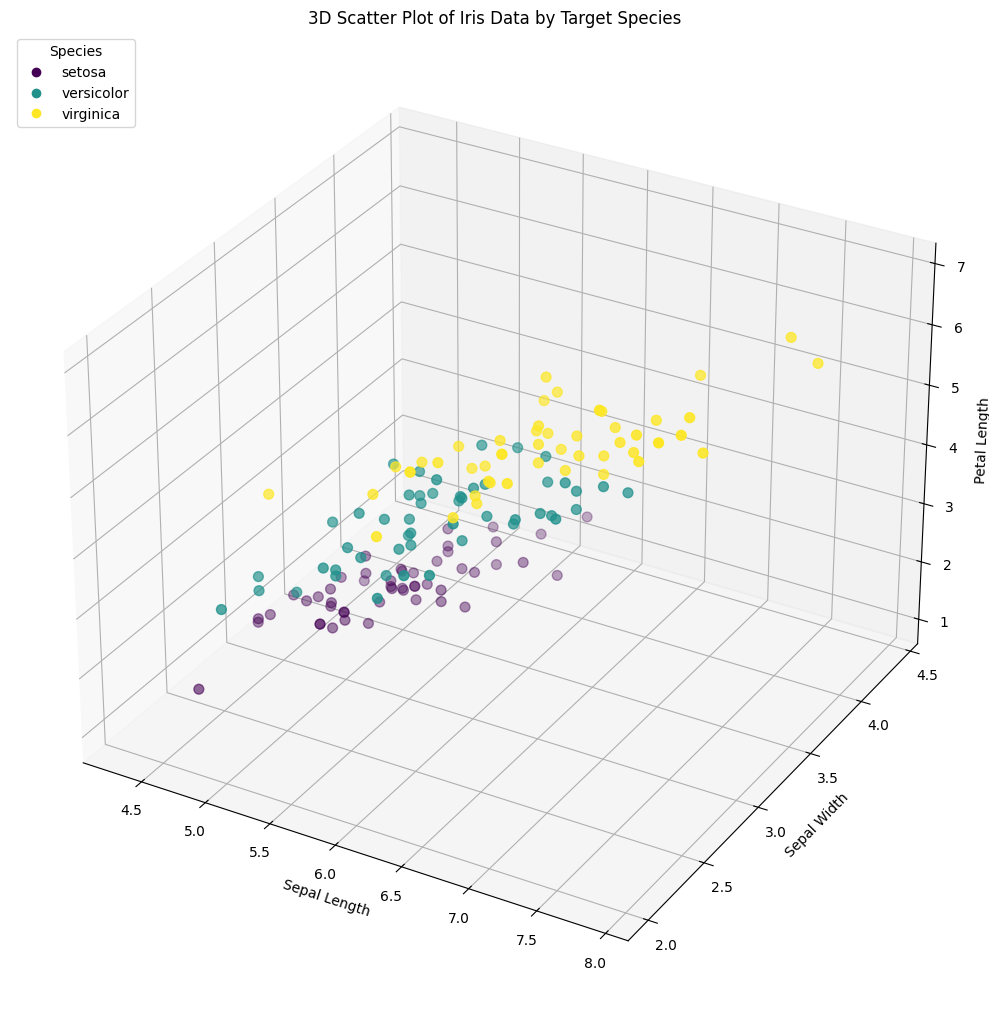

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot data points colored by target
scatter = ax.scatter(
    df['sepal length'],
    df['sepal width'],
    df['petal length'],
    c=df['target'], # Use numerical target for coloring
    cmap='viridis',
    s=50
)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Data by Target Species')

# Create a legend for the target species
legend_labels = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
handles, labels = scatter.legend_elements()
# Corrected: Use the handles directly and map the labels after cleaning
ax.legend(handles, [legend_labels[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels], title='Species', loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test =train_test_split(
    X,
    test_size=0.30,
    train_size=0.70,
    random_state=123,
    shuffle=True)

In [ ]:
print('X_train shape :', X_train.shape)
print('X_test shape :', X_test.shape)

X_train shape : (105, 3)
X_test shape : (45, 3)


In [ ]:
class KMeans:
    def __init__(self, k):
        self.k = k
        self.cluster_labels = None
    def fit(self, X):
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False), :]
        self.cluster_labels = np.arange(self.k)
        while True:
            distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
            self.clusters = np.argmin(distances, axis=0)
            new_centroids = np.array([X[self.clusters == i, :].mean(axis=0) for i in range(self.k)])
            # check convergence
            if np.array_equal(new_centroids, self.centroids):
                break
            else:
                self.centroids = new_centroids

    def predict(self, X):
        distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
        return self.cluster_labels[np.argmin(distances, axis=0)]

In [ ]:
model = KMeans(k=3)
model.fit(X_train)
kmeans_labels = model.predict(X_test)
cluster_coords = model.centroids
print('predicted_labels:', kmeans_labels)
print('cluster centroids:', cluster_coords)

predicted_labels: [2 1 1 2 0 2 2 0 0 2 1 0 2 1 1 1 0 0 2 0 0 1 0 2 0 0 0 2 1 0 1 2 0 0 2 2 1
 0 0 2 2 0 1 1 2]
cluster centroids: [[5.         3.415625   1.471875  ]
 [6.7862069  3.04482759 5.64827586]
 [5.89772727 2.78863636 4.36363636]]


In [ ]:
df['kmeans_labels'] = model.predict(X)

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_740/3538217273.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax.legend(handles, [legend_labels_kmeans[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels], title='K-Means Clusters', loc='upper left')


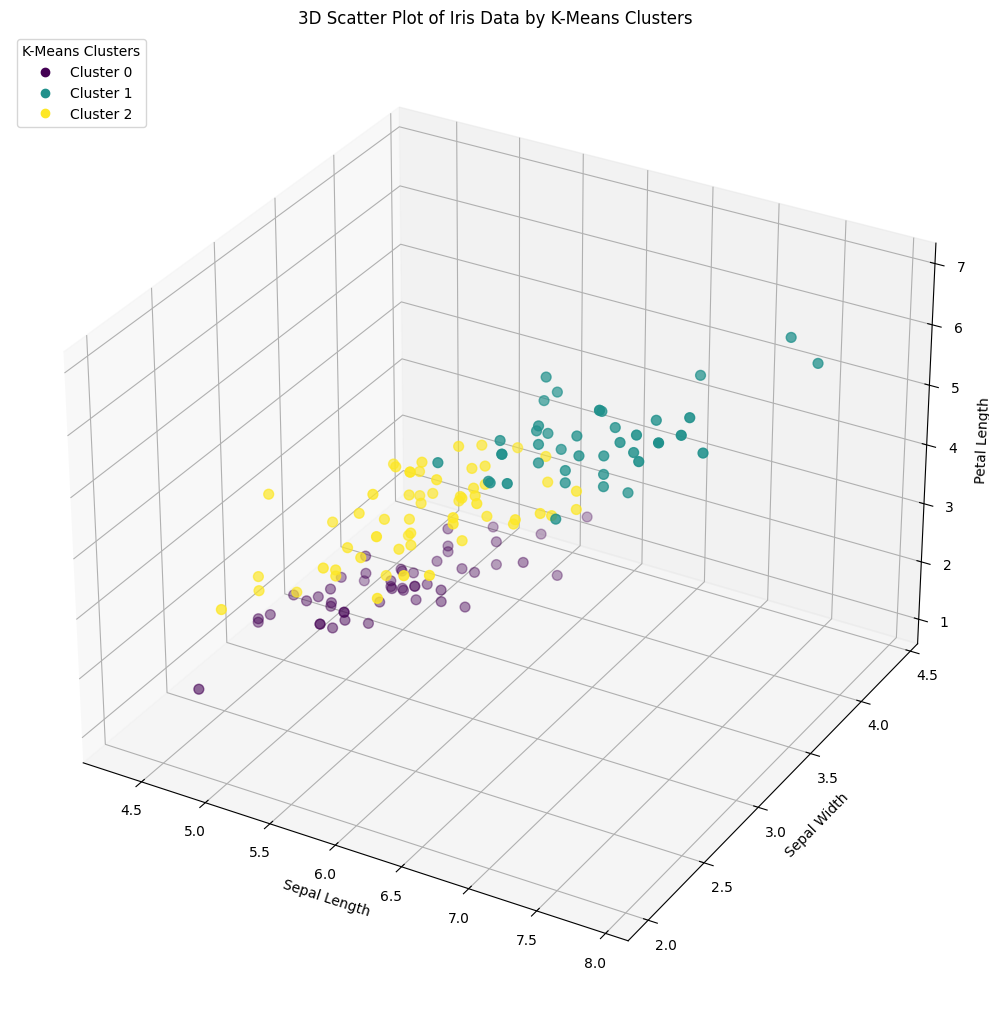

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot data points colored by kmeans_labels
scatter = ax.scatter(
    df['sepal length'],
    df['sepal width'],
    df['petal length'],
    c=df['kmeans_labels'], # Use kmeans_labels for coloring
    cmap='viridis',
    s=50
)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Data by K-Means Clusters')

# Create a legend for the kmeans_labels
legend_labels_kmeans = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
handles, labels = scatter.legend_elements()
ax.legend(handles, [legend_labels_kmeans[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels], title='K-Means Clusters', loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['sepal length', 'sepal width', 'petal length', 'target', 'species_name',
       'kmeans_labels'],
      dtype='object')

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_740/3130094799.py:38: SyntaxWarning: invalid escape sequence '\m'
  cleaned_labels_clusters = [legend_labels_kmeans[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]


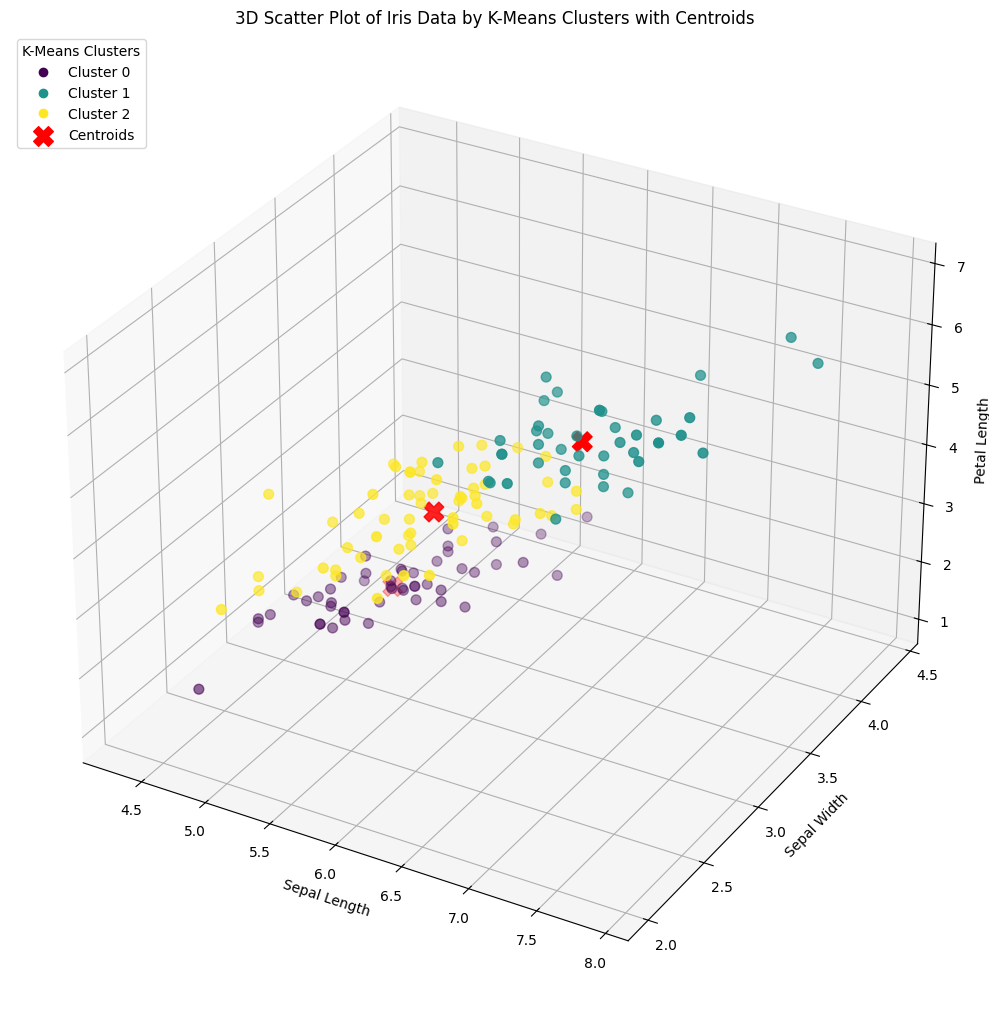

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot data points colored by kmeans_labels
scatter = ax.scatter(
    df['sepal length'],
    df['sepal width'],
    df['petal length'],
    c=df['kmeans_labels'], # Use kmeans_labels for coloring
    cmap='viridis',
    s=50
)

# Plot centroids
centroid_scatter = ax.scatter(
    cluster_coords[:, 0],
    cluster_coords[:, 1],
    cluster_coords[:, 2],
    marker='X',
    c='red',
    s=200,
    label='Centroids'
)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Data by K-Means Clusters with Centroids')

# Create a legend for the kmeans_labels and centroids
legend_labels_kmeans = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
handles_clusters, labels_clusters = scatter.legend_elements()

# Prepare labels for clusters by cleaning LaTeX formatting
cleaned_labels_clusters = [legend_labels_kmeans[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]

# Combine handles and labels for both clusters and centroids
all_handles = handles_clusters + [centroid_scatter]
all_labels = cleaned_labels_clusters + ['Centroids'] # Use the literal label for centroids

ax.legend(all_handles, all_labels, title='K-Means Clusters', loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
skmodel = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)

skmodel.fit(X_train)

KMeans(n_clusters=3)

In [ ]:
skmodel.labels_ # training labels

array([1, 2, 1, 0, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 0, 0, 2, 1,
       2, 2, 0, 1, 1, 1, 0, 2, 1, 2, 0, 2, 1, 0, 0, 1, 1, 2, 0, 0, 1, 0,
       1, 2, 0, 2, 0, 0, 2, 0, 0, 1, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 1, 1,
       1, 2, 2, 1, 1, 2, 0, 0, 1, 2, 2, 2, 2, 0, 1, 0, 1, 1, 0, 1, 2, 1,
       2, 2, 0, 1, 0, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2], dtype=int32)

In [ ]:
skmodel.predict(X_test) # predict labels, remember the integers do not make same sense in training and testing for clustering

array([1, 2, 2, 1, 0, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2,
       0, 1, 0, 0, 0, 1, 2, 0, 2, 1, 0, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 2,
       1], dtype=int32)

In [ ]:
skmodel_labels = skmodel.predict(X)

In [ ]:
df['skmodel_labels'] = skmodel_labels

<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_740/3584236847.py:41: SyntaxWarning: invalid escape sequence '\m'
  cleaned_labels_clusters = [legend_labels_skmeans[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]


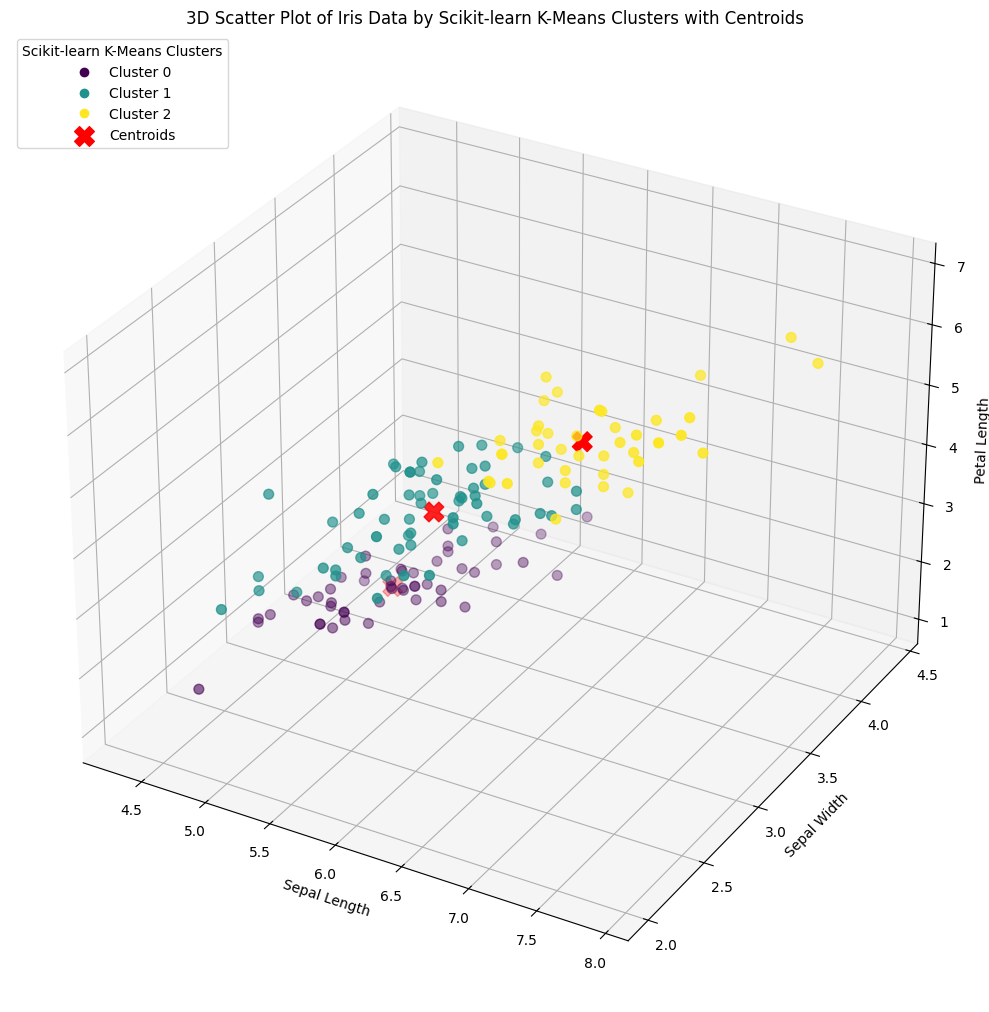

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot data points colored by skmodel_labels
scatter = ax.scatter(
    df['sepal length'],
    df['sepal width'],
    df['petal length'],
    c=df['skmodel_labels'], # Use skmodel_labels for coloring
    cmap='viridis',
    s=50
)

# Get centroids from scikit-learn model
sk_cluster_coords = skmodel.cluster_centers_

# Plot centroids
centroid_scatter = ax.scatter(
    sk_cluster_coords[:, 0],
    sk_cluster_coords[:, 1],
    sk_cluster_coords[:, 2],
    marker='X',
    c='red',
    s=200,
    label='Centroids'
)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Data by Scikit-learn K-Means Clusters with Centroids')

# Create a legend for the skmodel_labels and centroids
legend_labels_skmeans = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
handles_clusters, labels_clusters = scatter.legend_elements()

# Prepare labels for clusters by cleaning LaTeX formatting
cleaned_labels_clusters = [legend_labels_skmeans[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]

# Combine handles and labels for both clusters and centroids
all_handles = handles_clusters + [centroid_scatter]
all_labels = cleaned_labels_clusters + ['Centroids']

ax.legend(all_handles, all_labels, title='Scikit-learn K-Means Clusters', loc='upper left')

plt.tight_layout()
plt.show()

### Scikit-learn K-Means with 2 Clusters

<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_740/452250687.py:59: SyntaxWarning: invalid escape sequence '\m'
  cleaned_labels_clusters = [legend_labels_skmeans_2[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]


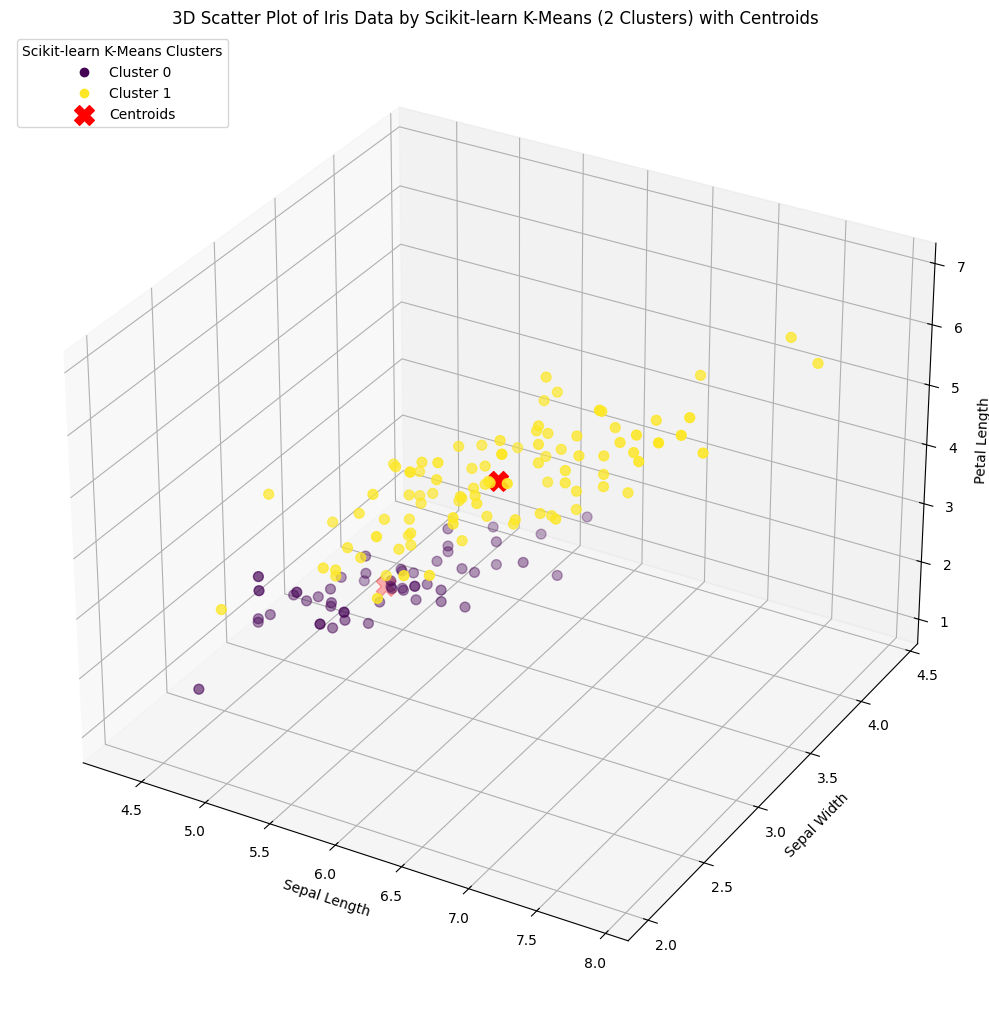

In [ ]:
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Initialize and fit scikit-learn K-Means model with 2 clusters
skmodel_2_clusters = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
skmodel_2_clusters.fit(X_train)

# Predict labels for the entire dataset
skmodel_labels_2_clusters = skmodel_2_clusters.predict(X)

# Get centroids from scikit-learn model
sk_cluster_coords_2 = skmodel_2_clusters.cluster_centers_

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot data points colored by skmodel_labels_2_clusters
scatter = ax.scatter(
    df['sepal length'],
    df['sepal width'],
    df['petal length'],
    c=skmodel_labels_2_clusters, # Use skmodel_labels_2_clusters for coloring
    cmap='viridis',
    s=50
)

# Plot centroids
centroid_scatter = ax.scatter(
    sk_cluster_coords_2[:, 0],
    sk_cluster_coords_2[:, 1],
    sk_cluster_coords_2[:, 2],
    marker='X',
    c='red',
    s=200,
    label='Centroids'
)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Data by Scikit-learn K-Means (2 Clusters) with Centroids')

# Create a legend for the skmodel_labels and centroids
legend_labels_skmeans_2 = {0: 'Cluster 0', 1: 'Cluster 1'}
handles_clusters, labels_clusters = scatter.legend_elements()

# Prepare labels for clusters by cleaning LaTeX formatting
cleaned_labels_clusters = [legend_labels_skmeans_2[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]

# Combine handles and labels for both clusters and centroids
all_handles = handles_clusters + [centroid_scatter]
all_labels = cleaned_labels_clusters + ['Centroids']

ax.legend(all_handles, all_labels, title='Scikit-learn K-Means Clusters', loc='upper left')

plt.tight_layout()
plt.show()


### Scikit-learn K-Means with 4 Clusters

<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_740/789643988.py:59: SyntaxWarning: invalid escape sequence '\m'
  cleaned_labels_clusters = [legend_labels_skmeans_4[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]


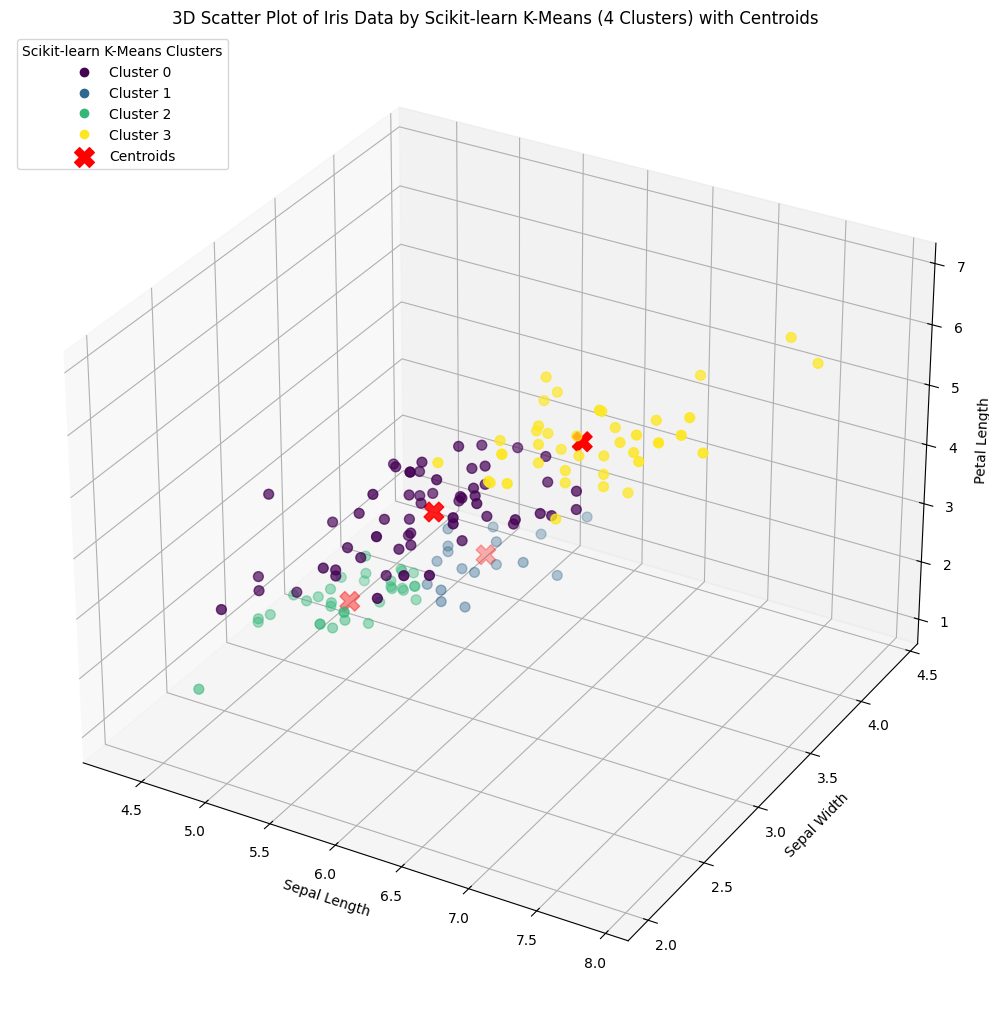

In [ ]:
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Initialize and fit scikit-learn K-Means model with 4 clusters
skmodel_4_clusters = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
skmodel_4_clusters.fit(X_train)

# Predict labels for the entire dataset
skmodel_labels_4_clusters = skmodel_4_clusters.predict(X)

# Get centroids from scikit-learn model
sk_cluster_coords_4 = skmodel_4_clusters.cluster_centers_

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot data points colored by skmodel_labels_4_clusters
scatter = ax.scatter(
    df['sepal length'],
    df['sepal width'],
    df['petal length'],
    c=skmodel_labels_4_clusters, # Use skmodel_labels_4_clusters for coloring
    cmap='viridis',
    s=50
)

# Plot centroids
centroid_scatter = ax.scatter(
    sk_cluster_coords_4[:, 0],
    sk_cluster_coords_4[:, 1],
    sk_cluster_coords_4[:, 2],
    marker='X',
    c='red',
    s=200,
    label='Centroids'
)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot of Iris Data by Scikit-learn K-Means (4 Clusters) with Centroids')

# Create a legend for the skmodel_labels and centroids
legend_labels_skmeans_4 = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
handles_clusters, labels_clusters = scatter.legend_elements()

# Prepare labels for clusters by cleaning LaTeX formatting
cleaned_labels_clusters = [legend_labels_skmeans_4[int(l.replace('$\mathdefault{', '').replace('}$', ''))] for l in labels_clusters]

# Combine handles and labels for both clusters and centroids
all_handles = handles_clusters + [centroid_scatter]
all_labels = cleaned_labels_clusters + ['Centroids']

ax.legend(all_handles, all_labels, title='Scikit-learn K-Means Clusters', loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
print('Custom KMeans Centroids:')
print(cluster_coords)

print('\nScikit-learn KMeans Centroids:')
print(skmodel.cluster_centers_)

Custom KMeans Centroids:
[[5.         3.415625   1.471875  ]
 [6.7862069  3.04482759 5.64827586]
 [5.89772727 2.78863636 4.36363636]]

Scikit-learn KMeans Centroids:
[[5.         3.415625   1.471875  ]
 [5.89772727 2.78863636 4.36363636]
 [6.7862069  3.04482759 5.64827586]]
